# STAT 443 — ILI Forecast Comparison Plots
**Karl Estampador, Pascal Gamma, Michael Güntert**

This notebook reproduces the two main-body plots for the project report:
1. **Rolling one-step-ahead forecasts vs. actual ILI** over the 2023–2024 holdout (all five models)
2. **Rolling absolute forecast error over time** by model

All five models are re-run here from scratch so the plots are fully self-contained and reproducible. Run `data_cleaning.ipynb` first to generate the `.rds` files in `fluview_clean/`.


## 1. Packages

In [1]:
library(tidyverse)
library(tsibble)
library(fable)
library(fabletools)
library(feasts)
library(lubridate)
library(forecast)   # needed for rolling_arimax_base → arima()

options(repr.plot.width = 14, repr.plot.height = 5, repr.plot.res = 150)


Warning message:
"package 'tidyverse' was built under R version 4.5.3"
Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Warning message:
"package 'tibble' was built under R version 4.5.3"
Warning message:
"package 'tidyr' was built under R version 4.5.3"
Warning message:
"package 'readr' was built under R version 4.5.3"
Warning message:
"package 'purrr' was built under R version 4.5.3"
Warning message:
"package 'dplyr' was built under R version 4.5.3"
Warning message:
"package 'stringr' was built under R version 4.5.2"
Warning message:
"package 'forcats' was built under R version 4.5.2"
Warning message:
"package 'lubridate' was built under R version 4.5.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────

## 2. Load cleaned data

In [2]:
# Produced by data_cleaning.ipynb
df_lagged    <- readr::read_rds("fluview_clean/df_lagged.rds")
train_full   <- readr::read_rds("fluview_clean/train_full.rds")
holdout      <- readr::read_rds("fluview_clean/holdout.rds")
n_train_init <- nrow(train_full)

cat("Total rows :", nrow(df_lagged), "\n")
cat("Training rows:", n_train_init, "\n")
cat("Holdout range:", as.character(min(holdout$week_start)),
    "to", as.character(max(holdout$week_start)), "\n")


Total rows : 1198 
Training rows: 1094 
Holdout range: 2023 W01 to 2024 W52 


## 3. Rolling one-step-ahead helper functions

`rolling_rmse()` handles fable-based models (ETS, ARIMA).  
`rolling_arimax_base()` handles ARIMAX via base `arima()` (needed to pass `xreg`).


In [3]:
# ── fable-based rolling evaluator ───────────────────────────────────────────
rolling_rmse <- function(data, model_expr, model_name, min_train = n_train_init) {
  stretched <- data %>%
    stretch_tsibble(.init = min_train, .step = 1)

  rolling_fits <- rlang::inject(
    model(stretched, mod = !!model_expr)
  )

  rolling_fc <- rolling_fits %>%
    forecast(h = 1)

  actuals <- data %>%
    as_tibble() %>%
    select(week_start, actual = percent_weighted_ili)

  rolling_fc %>%
    as_tibble() %>%
    left_join(actuals, by = "week_start") %>%
    mutate(
      model    = model_name,
      forecast = .mean,
      sq_error = (actual - forecast)^2
    ) %>%
    select(model, week_start, actual, forecast, sq_error)
}

# ── base-arima rolling evaluator (ARIMAX) ────────────────────────────────────
rolling_arimax_base <- function(data,
                                covariate_cols,
                                model_name    = NULL,
                                order         = c(1, 1, 0),
                                seasonal      = list(order = c(1, 1, 0), period = 52),
                                min_train     = n_train_init,
                                method        = "CSS") {
  df_tb     <- as_tibble(data)
  n         <- nrow(df_tb)
  forecasts <- rep(NA_real_, n)

  for (t in (min_train + 1):n) {
    train_y <- df_tb$percent_weighted_ili[1:(t - 1)]
    train_x <- as.matrix(df_tb[1:(t - 1), covariate_cols])
    new_x   <- as.matrix(df_tb[t,          covariate_cols])

    fit <- tryCatch(
      arima(train_y, order = order, seasonal = seasonal,
            xreg = train_x, method = method),
      error = function(e) tryCatch(
        arima(train_y, order = order, seasonal = seasonal,
              xreg = train_x, method = "CSS"),
        error = function(e2) NULL
      )
    )
    if (!is.null(fit))
      forecasts[t] <- predict(fit, n.ahead = 1, newxreg = new_x)$pred[1]
  }

  label <- if (!is.null(model_name)) model_name else paste(covariate_cols, collapse = " + ")

  tibble(
    model      = label,
    week_start = df_tb$week_start,
    actual     = df_tb$percent_weighted_ili,
    forecast   = forecasts
  ) %>%
    filter(!is.na(forecast)) %>%
    mutate(sq_error = (actual - forecast)^2)
}


## 4. Fit all five models

⚠️ **Runtime note:** Each rolling fit re-trains the model at every holdout week (104 steps). The ARIMA and ARIMAX models take several minutes each. Run the cells below sequentially and let them finish before proceeding to the plots.


### 4a. Baselines — Persistence (SNaive) and Training Mean

In [4]:
cat("Fitting rolling MEAN baseline...\n")
res_mean <- rolling_rmse(
  df_lagged,
  expr(MEAN(percent_weighted_ili)),
  "Mean"
)

cat("Fitting rolling PERSISTENCE (SNaive) baseline...\n")
res_snaive <- rolling_rmse(
  df_lagged,
  expr(SNAIVE(percent_weighted_ili ~ lag(52))),
  "SNaive"
)

cat("Baselines done.\n")


Fitting rolling MEAN baseline...
Fitting rolling PERSISTENCE (SNaive) baseline...
Baselines done.


### 4b. Exponential Smoothing — STL + ETS(A, Ad, N)

In [5]:
cat("Fitting rolling STL+ETS...\n")
res_ets <- rolling_rmse(
  df_lagged,
  expr(
    decomposition_model(
      STL(percent_weighted_ili ~ season(period = 52)),
      ETS(season_adjust ~ error("A") + trend("Ad"))
    )
  ),
  "STL+ETS"
)
cat("STL+ETS done.\n")


Fitting rolling STL+ETS...


Warning message:
"Seasonal periods (`period`) of length greather than 24 are not supported by
ETS. Seasonality will be ignored."
Warning message:
"Seasonal periods (`period`) of length greather than 24 are not supported by
ETS. Seasonality will be ignored."
Warning message:
"Seasonal periods (`period`) of length greather than 24 are not supported by
ETS. Seasonality will be ignored."
Warning message:
"Seasonal periods (`period`) of length greather than 24 are not supported by
ETS. Seasonality will be ignored."
Warning message:
"Seasonal periods (`period`) of length greather than 24 are not supported by
ETS. Seasonality will be ignored."
Warning message:
"Seasonal periods (`period`) of length greather than 24 are not supported by
ETS. Seasonality will be ignored."
Warning message:
"Seasonal periods (`period`) of length greather than 24 are not supported by
ETS. Seasonality will be ignored."
Warning message:
"Seasonal periods (`period`) of length greather than 24 are not supported by
ETS

STL+ETS done.


### 4c. ARIMA(1,1,2)(2,0,0)[52] — best pure ARIMA

In [6]:
cat("Fitting rolling ARIMA(1,1,2)(2,0,0)[52]...\n")
res_arima <- rolling_rmse(
  df_lagged,
  expr(ARIMA(percent_weighted_ili ~ pdq(1,1,2) + PDQ(2,0,0))),
  "ARIMA(1,1,2)(2,0,0)[52]"
)
cat("ARIMA done.\n")


Fitting rolling ARIMA(1,1,2)(2,0,0)[52]...


Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIM

ARIMA done.


### 4d. ARIMAX(1,1,0)(1,1,0)[52] — best ARIMAX (age 5–24, lag 1)

In [7]:
cat("Fitting rolling ARIMAX(1,1,0)(1,1,0)[52] with d_age_5_24_lag1...\n")
res_arimax <- rolling_arimax_base(
  df_lagged,
  covariate_cols = "d_age_5_24_lag1",
  model_name     = "ARIMAX(1,1,0)(1,1,0)[52]",
  order          = c(1, 1, 0),
  seasonal       = list(order = c(1, 1, 0), period = 52),
  method         = "CSS"
)
cat("ARIMAX done.\n")


Fitting rolling ARIMAX(1,1,0)(1,1,0)[52] with d_age_5_24_lag1...
ARIMAX done.


## 5. Combine results and verify RMSE values

In [10]:
# The fable-based results (res_mean, res_snaive, res_ets, res_arima) carry a
# yearweek index for week_start; res_arimax uses a plain Date from base arima().
# as.character() on yearweek produces "YYYY Www" which charToDate() rejects.
# Fix: convert yearweek -> Date via as.Date() before binding.

fable_to_date <- function(df) {
  df %>%
    as_tibble() %>%
    mutate(week_start = as.Date(week_start))
}

# Stack all results, filter to holdout window only
all_results <- bind_rows(
  fable_to_date(res_mean),
  fable_to_date(res_snaive),
  fable_to_date(res_ets),
  fable_to_date(res_arima),
  res_arimax %>% as_tibble() %>% mutate(week_start = as.Date(week_start))
) %>%
  filter(week_start %in% as.Date(holdout$week_start)) %>%
  mutate(week_date = week_start)

# Quick RMSE sanity check — should match Table 5 in the report
rmse_check <- all_results %>%
  group_by(model) %>%
  summarise(
    RMSE = round(sqrt(mean(sq_error, na.rm = TRUE)), 3),
    n    = sum(!is.na(sq_error)),
    .groups = "drop"
  ) %>%
  arrange(RMSE)

print(rmse_check)


# A tibble: 5 × 3
  model                     RMSE     n
  <chr>                    <dbl> <int>
1 ARIMA(1,1,2)(2,0,0)[52]  0.216    93
2 ARIMAX(1,1,0)(1,1,0)[52] 0.25    104
3 STL+ETS                  0.304   104
4 SNaive                   1.01    104
5 Mean                     1.40    104


## 6. Plot 1 — Rolling one-step-ahead forecasts vs. actual ILI

This is the primary forecast comparison plot for the main body of the report.  
The baselines (Mean, SNaive) are shown as dashed lines to keep the ARIMA/ARIMAX/ETS lines readable.


Saved: fluview_clean/plot1_forecast_vs_actual.png


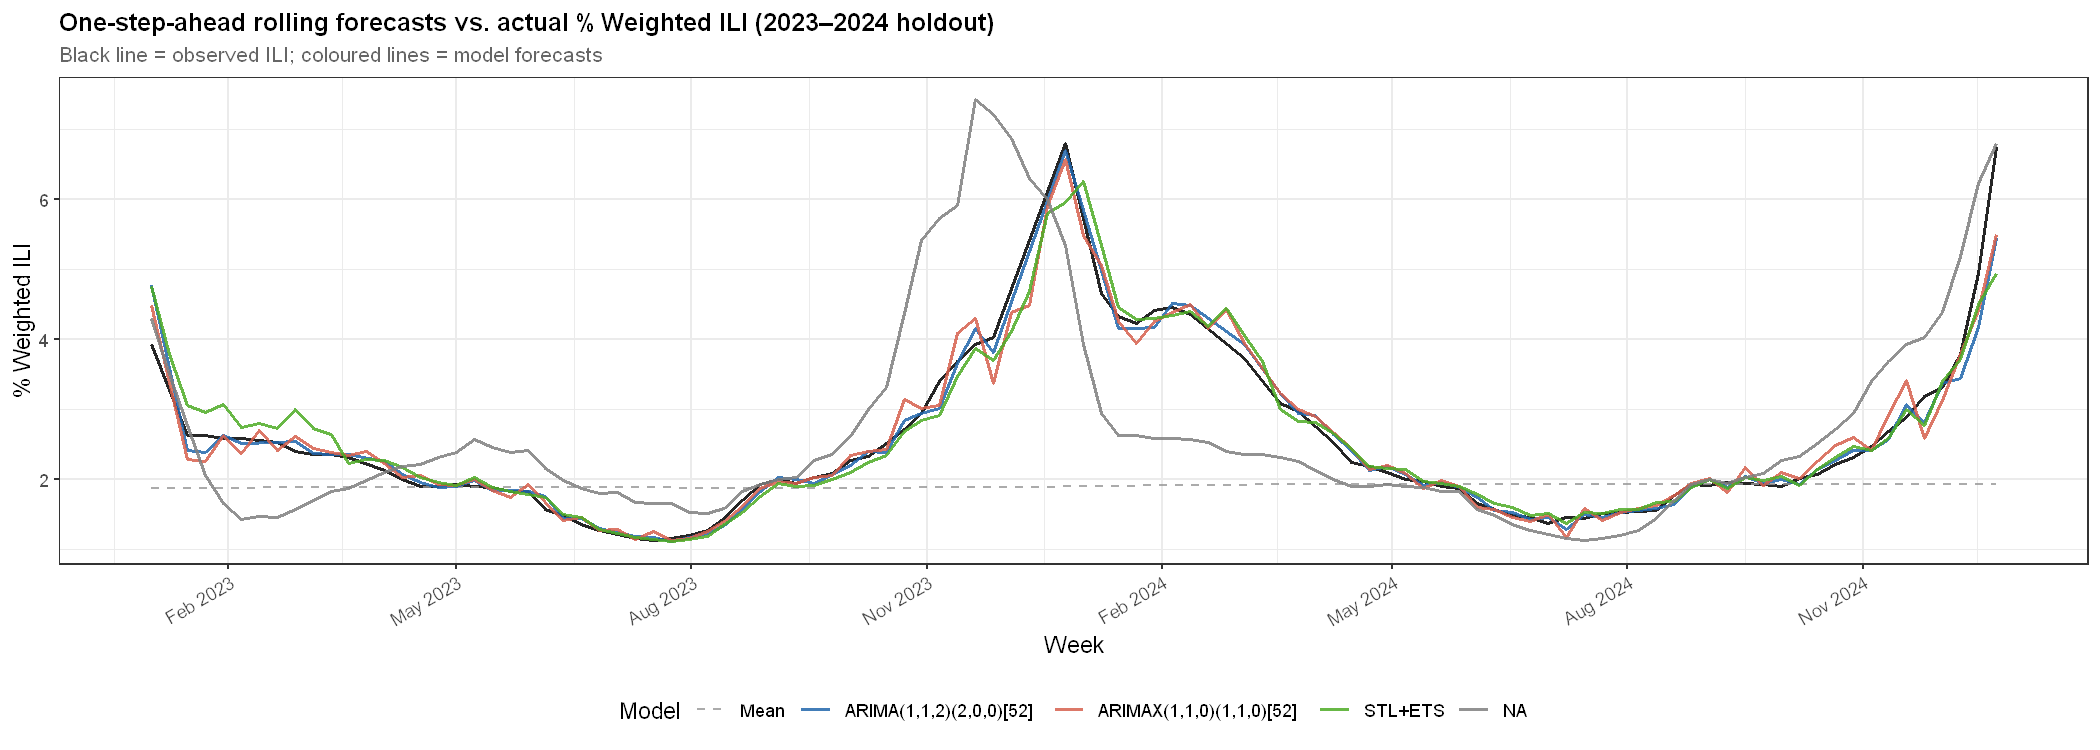

In [ ]:
options(repr.plot.width = 14, repr.plot.height = 5, repr.plot.res = 150)

# Separate baselines from models so they can be styled differently
model_levels <- c(
  "ARIMA(1,1,2)(2,0,0)[52]",
  "ARIMAX(1,1,0)(1,1,0)[52]",
  "STL+ETS",
  "Mean",
  "SNaive"
)

plot_data <- all_results %>%
  filter(!is.na(forecast)) %>%
  mutate(model = factor(model, levels = model_levels))

# Actual series (one copy — use any model row since actual is the same)
actuals_line <- plot_data %>%
  filter(model == "ARIMA(1,1,2)(2,0,0)[52]") %>%
  select(week_date, actual)

# Colour palette: models first, then baselines muted
pal <- c(
  "ARIMA(1,1,2)(2,0,0)[52]"  = "#2166ac",
  "ARIMAX(1,1,0)(1,1,0)[52]" = "#d6604d",
  "STL+ETS"                  = "#4dac26",
  "Mean"                     = "#969696",
  "SNaive"                   = "#bdbdbd"
)

p1 <- ggplot() +
  # Actual ILI
  geom_line(data = actuals_line,
            aes(x = week_date, y = actual),
            colour = "black", linewidth = 0.7, alpha = 0.85) +
  # Baseline forecasts — dashed
  geom_line(data = plot_data %>% filter(model %in% c("Mean", "SNaive")),
            aes(x = week_date, y = forecast, colour = model),
            linewidth = 0.55, linetype = "dashed", alpha = 0.8) +
  # Model forecasts — solid
  geom_line(data = plot_data %>% filter(!model %in% c("Mean", "SNaive")),
            aes(x = week_date, y = forecast, colour = model),
            linewidth = 0.7, alpha = 0.85) +
  scale_colour_manual(values = pal, name = "Model") +
  scale_x_date(date_breaks = "3 months", date_labels = "%b %Y") +
  labs(
    title    = "One-step-ahead rolling forecasts vs. actual % Weighted ILI (2023–2024 holdout)",
    subtitle = "Black line = observed ILI; coloured lines = model forecasts",
    x        = "Week",
    y        = "% Weighted ILI"
  ) +
  theme_bw(base_size = 11) +
  theme(
    legend.position  = "bottom",
    axis.text.x      = element_text(angle = 30, hjust = 1),
    plot.title       = element_text(face = "bold", size = 12),
    plot.subtitle    = element_text(size = 10, colour = "grey40")
  )

print(p1)

# Save for report
ggsave("fluview_clean/plot1_forecast_vs_actual.png",
       plot = p1, width = 14, height = 5, dpi = 300)
cat("Saved: fluview_clean/plot1_forecast_vs_actual.png\n")


## 7. Plot 2 — Rolling absolute forecast error over time

Shows *when* each model struggles. Peaks correspond to rapid rises or falls in ILI around flu season transitions — a useful companion to the RMSE table.


Saved: fluview_clean/plot2_abs_errors.png


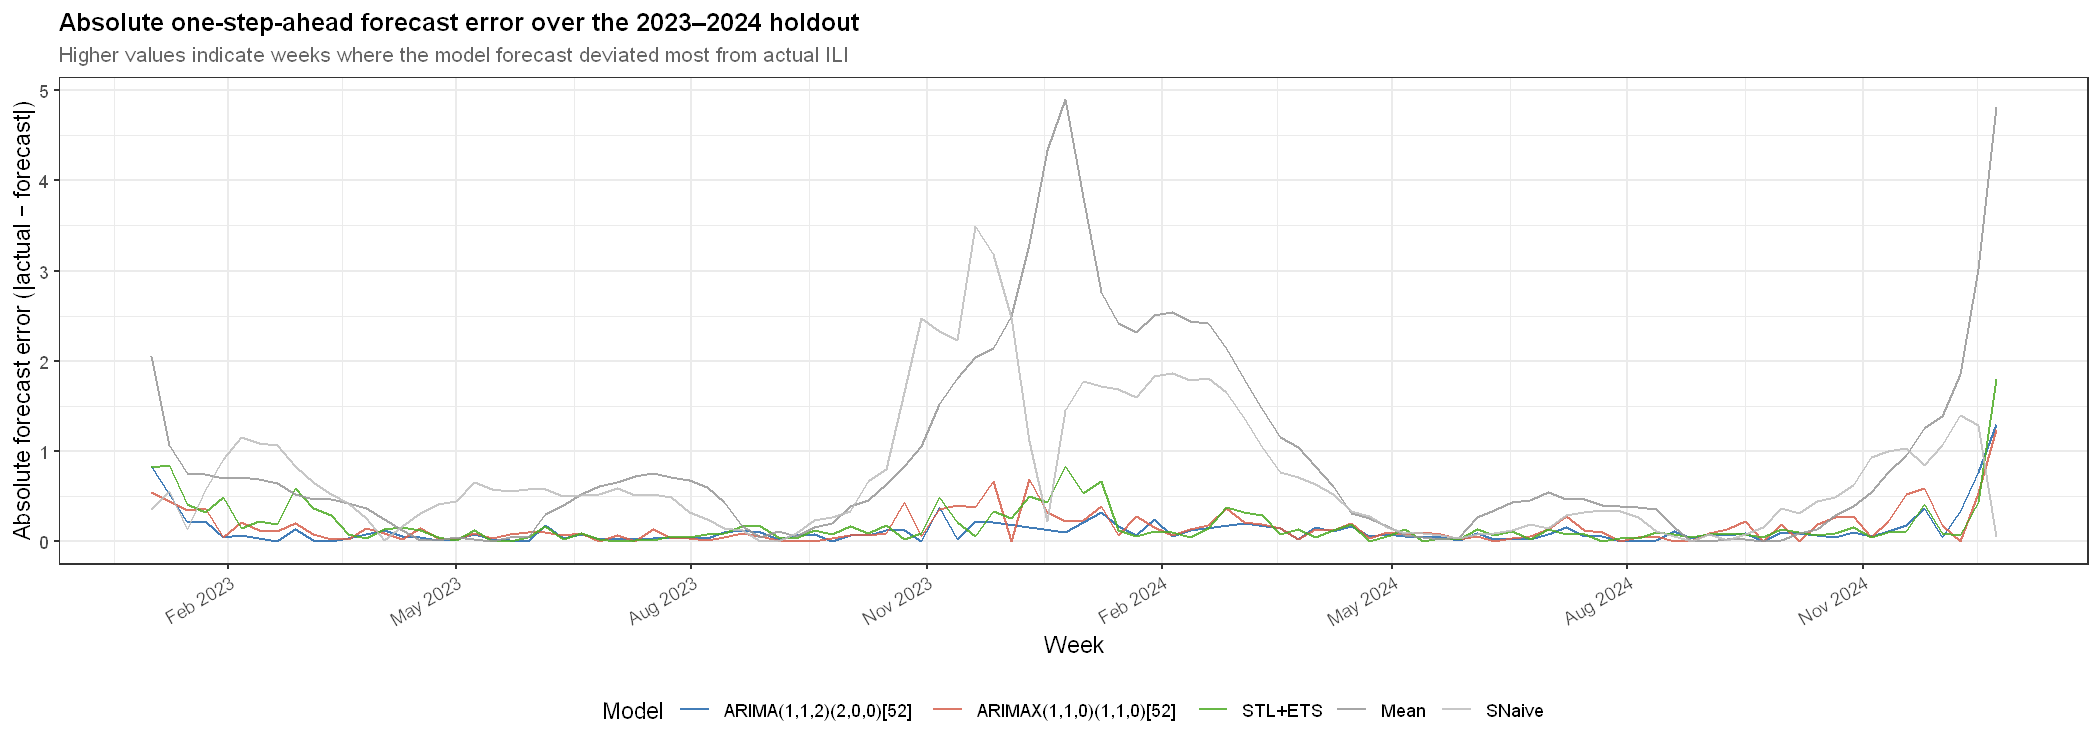

In [12]:
options(repr.plot.width = 14, repr.plot.height = 5, repr.plot.res = 150)

p2 <- all_results %>%
  filter(!is.na(sq_error)) %>%
  mutate(
    abs_error = sqrt(sq_error),
    model     = factor(model, levels = model_levels)
  ) %>%
  ggplot(aes(x = week_date, y = abs_error, colour = model)) +
  geom_line(linewidth = 0.65, alpha = 0.85) +
  scale_colour_manual(values = pal, name = "Model") +
  scale_x_date(date_breaks = "3 months", date_labels = "%b %Y") +
  labs(
    title    = "Absolute one-step-ahead forecast error over the 2023–2024 holdout",
    subtitle = "Higher values indicate weeks where the model forecast deviated most from actual ILI",
    x        = "Week",
    y        = "Absolute forecast error (|actual − forecast|)"
  ) +
  theme_bw(base_size = 11) +
  theme(
    legend.position = "bottom",
    axis.text.x     = element_text(angle = 30, hjust = 1),
    plot.title      = element_text(face = "bold", size = 12),
    plot.subtitle   = element_text(size = 10, colour = "grey40")
  )

print(p2)

# Save for report
ggsave("fluview_clean/plot2_abs_errors.png",
       plot = p2, width = 14, height = 5, dpi = 300)
cat("Saved: fluview_clean/plot2_abs_errors.png\n")


## 8. Session info

In [13]:
sessionInfo()

R version 4.5.1 (2025-06-13 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_Canada.utf8  LC_CTYPE=English_Canada.utf8   
[3] LC_MONETARY=English_Canada.utf8 LC_NUMERIC=C                   
[5] LC_TIME=English_Canada.utf8    

time zone: America/Vancouver
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] forecast_9.0.2   feasts_0.5.0     fable_0.5.0      fabletools_0.6.1
 [5] tsibble_1.2.0    lubridate_1.9.5  forcats_1.0.1    stringr_1.6.0   
 [9] dplyr_1.2.0      purrr_1.2.1      readr_2.2.0      tidyr_1.3.2     
[13] tibble_3.3.1     ggplot2_4.0.2    tidyverse_2.0.0 

loaded via a namespace (and not attached):
 [1] utf8_1.2.6           generics_0.1.4       anytime_0.3.12      
 [4] lattice_0.22-7       stringi_1.8.7        hms_1.1.4           
 [7] digest_0.6.39      